In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm


mpl.rcParams.update({
    "font.family": "serif",
    "text.usetex": True,
    "text.latex.preamble": r"\usepackage{amsmath}",
    "errorbar.capsize": 5,
    "axes.linewidth": 2,
    "xtick.major.size": 16,
    "xtick.major.width": 2,
    "xtick.minor.size": 8,
    "xtick.minor.width": 1,
    "ytick.major.size": 16,
    "ytick.major.width": 2,
    "ytick.minor.size": 8,
    "ytick.minor.width": 1,
    "axes.labelsize": 30,
    "xtick.labelsize": 30,
    "ytick.labelsize": 30,
    "legend.fontsize": 18,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "ytick.right": True,
    "xtick.top": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "legend.title_fontsize": 18,
})


In [2]:
def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object to a pandas DataFrame.
    """
    table = Table(fits_rec)

    # Keep only 1D columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]

    df = table[cols].to_pandas()
    df = decode(df)

    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin x_col and compute median of y_col in each bin.
    Returns median and counts.
    """
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    grouped = df.groupby(x_bin_labels, observed=False).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)
    grouped = grouped.rename(columns={
        x_col: 'x_bin',
        'y_median': f'{y_col}_median'
    })

    return grouped



from getdist import plots, MCSamples
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Color-blind–safe palette
LOW_COLOR  = "#0072B2"   # blue
HIGH_COLOR = "#D55E00"   # vermillion

# GetDist density helper functions
def get_density(x, y):
    arr = np.vstack((x, y)).T
    samples = MCSamples(samples=arr, names=["x", "y"])
    g = plots.get_single_plotter()
    X, Y = g.get_param_array(samples, ["x", "y"])
    dens = g.sample_analyser.get_density_grid(samples, X, Y)
    return dens


def plot_sigma_contours(ax, dens, color):
    """
    1σ: filled + outline
    2σ: outline only
    """
    level_1s = dens.getContourLevels([0.6827])[0]
    level_2s = dens.getContourLevels([0.9545])[0]

    X = dens.x
    Y = dens.y
    P = dens.P

    # --- 1σ filled ---
    ax.contourf(
        X, Y, P,
        levels=[level_1s, np.max(P)],
        colors=[color + "55"],
        zorder=2
    )

    # --- 1σ outline ---
    ax.contour(
        X, Y, P,
        levels=[level_1s],
        colors=[color],
        linewidths=2.5,
        zorder=3
    )

    # --- 2σ outline ---
    ax.contour(
        X, Y, P,
        levels=[level_2s],
        colors=[color],
        linewidths=1.5,
        linestyles="--",
        zorder=3
    )

import numpy as np
import matplotlib.pyplot as plt
from getdist import plots, MCSamples
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Color-blind–safe palette
LOW_COLOR  = "#0072B2"   # blue
HIGH_COLOR = "#D55E00"   # vermillion

# GetDist density helper functions
def get_density(x, y):
    arr = np.vstack((x, y)).T
    samples = MCSamples(samples=arr, names=["x", "y"])
    g = plots.get_single_plotter()
    X, Y = g.get_param_array(samples, ["x", "y"])
    dens = g.sample_analyser.get_density_grid(samples, X, Y)
    return dens


def plot_1sigma_contour(ax, dens, color):
    level_1s = dens.getContourLevels([0.6827])[0]

    X, Y, P = dens.x, dens.y, dens.P

    # 1σ filled
    ax.contourf(
        X, Y, P,
        levels=[level_1s, np.max(P)],
        colors=[color + "55"],
        zorder=2
    )

    # 1σ outline
    #ax.contour(X, Y, P, levels=[level_1s], colors=[color],linewidths=2.0,zorder=3)

In [3]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

In [4]:
data = data[~data['MN_MG'].isna()]
data_high_alpha = data[data['high_low_alpha'] == "high"]
data_low_alpha = data[data['high_low_alpha'] == "low"]

In [5]:
from chemevo import evolution as evo

mg_h_big_bin_edges = np.arange(-0.8, 0.4, 0.2) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)

xs = np.linspace(-1, 1, 100)

def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

etas = [0, 0.5, 1]
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
colors_lines = ['blue', 'orange', 'green', 'red', 'purple', 'teal', 'magenta', 'brown', 'navy', 'maroon']
colors_dots = ['greenyellow', 'cyan', 'orange', 'blue', 'red', 'yellow', 'green', 'gray', 'peru', 'navy']


def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

tau_1s = [2, 5, 5]
tau_2s = [6, 10, 20]
sfr_1 = rise_fall(t_array, tau_1s[0], tau_2s[0])
sfr_2 = rise_fall(t_array, tau_1s[1], tau_2s[1])
sfr_3 = rise_fall(t_array, tau_1s[2], tau_2s[2])
mask = t_array <= 6
t_array_cut = t_array[mask]
sfr_1 = sfr_1[mask]

# Normalize each SFR so integral over time equals 1
sfr_1 /= np.trapezoid(sfr_1, t_array_cut)
sfr_2 /= np.trapezoid(sfr_2, t_array)
sfr_3 /= np.trapezoid(sfr_3, t_array)

sfrs = [sfr_1, sfr_2, sfr_3]


gals_taustar_eta0 = []
gals_taustar_eta1 = []
gals_taustar_eta2 = []

#gals_taustar_sfrconst = []
gals_taustar_sfrexp = []
gals_taustar_sfr1 = []
gals_taustar_sfr2 = []
gals_taustar_sfr3 = []


gals_eta = []
gals_sfr = []


for i in range(len(tau_stars)):
    gals_taustar_eta0.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_eta1.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[1]))

for i in range(len(tau_stars)):
    gals_taustar_eta2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=tau_stars[i], eta=etas[2]))



for i in range(len(tau_stars)):
    gals_taustar_sfrexp.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_exp, tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr1.append(evo.Galaxy(t_array=t_array_cut, yields_ref="W2024,1.3", m_g_array=sfrs[0], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr2.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[1], tau_star=tau_stars[i], eta=etas[0]))

for i in range(len(tau_stars)):
    gals_taustar_sfr3.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[2], tau_star=tau_stars[i], eta=etas[0]))



for j in range(len(etas)):
    gals_eta.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=m_g_array_const, tau_star=1, eta=etas[j]))

#for k in range(len(sfrs)):
#    gals_sfr.append(evo.Galaxy(t_array=t_array, yields_ref="W2024,1.3", m_g_array=sfrs[k], tau_star=1, eta=0))

Text(0, 0.5, 'SFR')

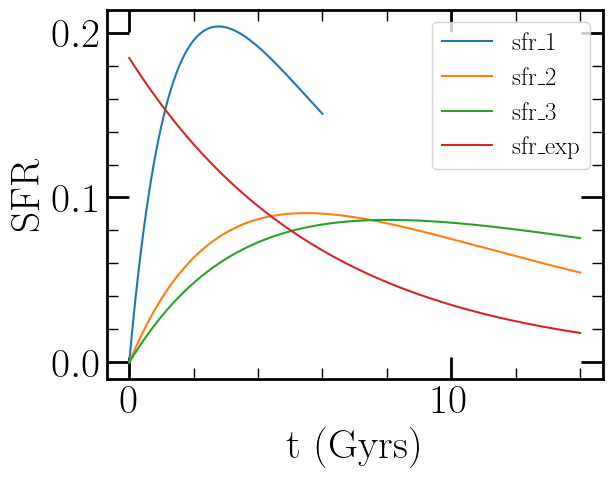

In [6]:
plt.plot(t_array_cut, sfr_1, label = 'sfr_1')

for i in range(1,len(sfrs)):
    plt.plot(t_array, sfrs[i], label = f'sfr_{i+1}')

plt.plot(t_array, m_g_array_exp, label = r'sfr_{exp}')
plt.legend(loc = 'upper right')
plt.xlabel('t (Gyrs)')
plt.ylabel('SFR')

In [7]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            o_h = gal.O_H
            for indx in range(len(o_h)):
                o_h_at_time = o_h[indx]
                if o_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals


gals_endpoints = {
    0: find_endpoints(gals_taustar_eta0, mg_h_big_bin_centers),
    1: find_endpoints(gals_taustar_eta1, mg_h_big_bin_centers),
    2: find_endpoints(gals_taustar_eta2, mg_h_big_bin_centers),
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

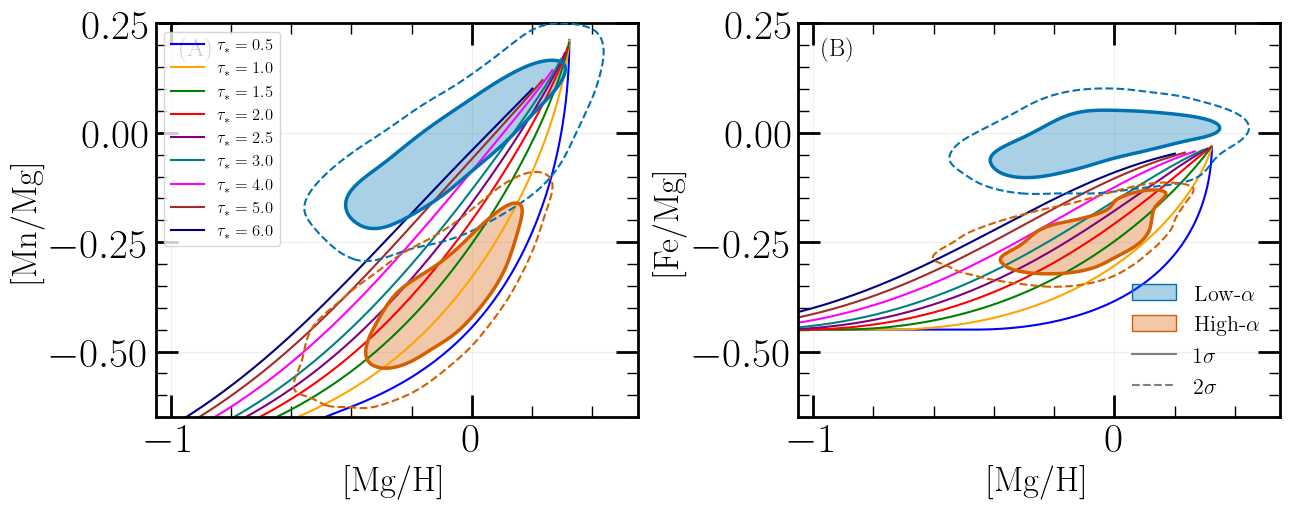

In [8]:
# Compute densities
dens_mnmg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["MN_MG"])
dens_mnmg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["MN_MG"])

dens_femg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["FE_MG"])
dens_femg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["FE_MG"])

# Figure 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel A — [Mn/Mg]
ax = axes[0]
plot_sigma_contours(ax, dens_mnmg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_mnmg_high, HIGH_COLOR)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    ax.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-', label = rf'$\tau_* = {gal.tau_star_arr[0]}$')
ax.legend(loc='upper left', fontsize=12)
ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Mn/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(A)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Panel B — [Fe/Mg]
ax = axes[1]
plot_sigma_contours(ax, dens_femg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_femg_high, HIGH_COLOR)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    ax.plot(gal.O_H, gal.Fe_O, color = colors_lines[i], linestyle='-')

ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Fe/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

#ax.set_box_aspect(1)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(B)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Legend (σ regions + populations + medians)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR,
                  label=r"Low-$\alpha$")

HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR,
                   label=r"High-$\alpha$")

SIG1 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="-", label=r"$1\sigma$")
SIG2 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="--", label=r"$2\sigma$")


ax.legend(
    handles=[LOW_PATCH, HIGH_PATCH, SIG1, SIG2],
    frameon=False, loc="lower right", fontsize=16,
)

plt.tight_layout()
plt.show()


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


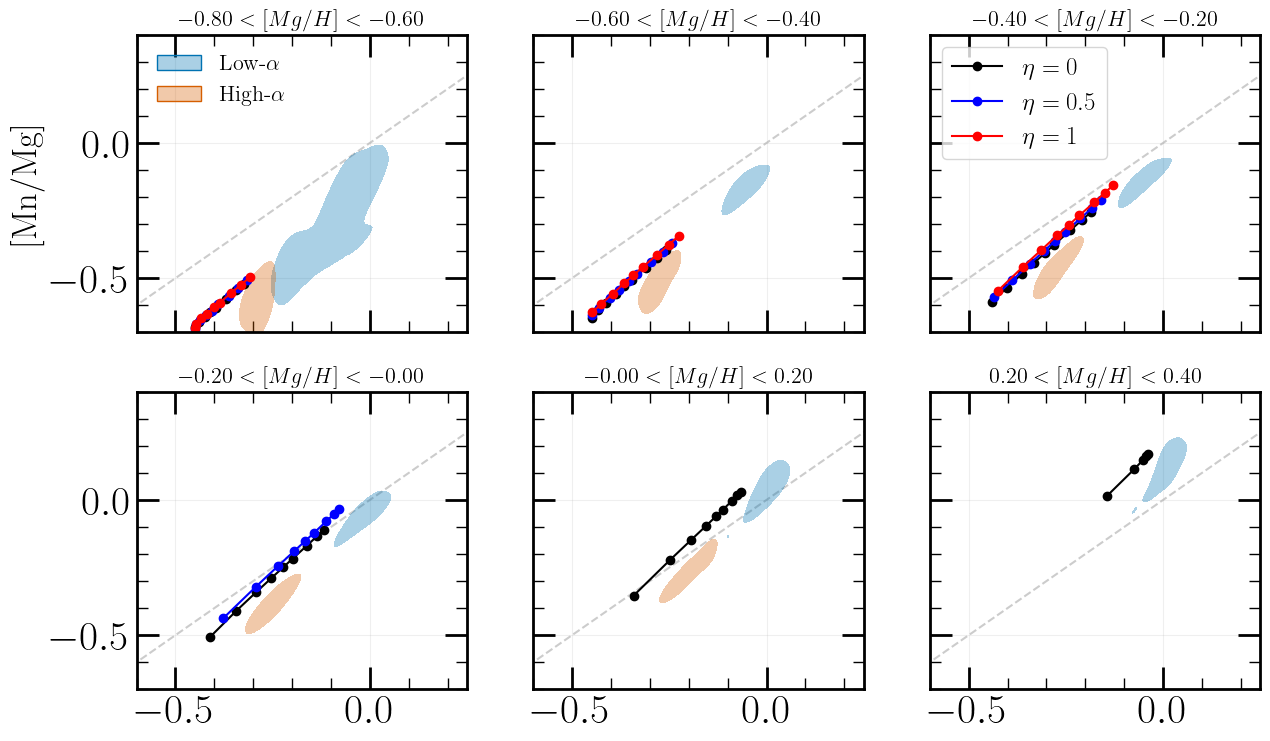

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [9]:
# Figure: 2 rows × 3 columns (panels 1–6)
fig, axes = plt.subplots(
    2, 3,
    figsize=(14.5, 8.5),
    sharex=True,
    sharey=True
)
axes = axes.flatten()
panel_ids = range(0, 6)  # panels 1–6 only

# Letters for panel labels
panel_labels = ["(A)", "(B)", "(C)", "(D)", "(E)", "(F)"]


# Loop over panels
for idx, (ax, i) in enumerate(zip(axes, panel_ids)):

    df = data[data['MG_H_big_bin'] == i]
    df = downsample(df, 5000)


    # Diagonal reference line
    xs = np.linspace(-0.8, 0.4, 200)
    ax.plot(xs, xs, '--', color='gray', alpha=0.4, zorder=0)

    # KDE + 1σ contours per α population
    for label, color in [("low", LOW_COLOR), ("high", HIGH_COLOR)]:
        sub = df[df['high_low_alpha'] == label]
        if len(sub) < 200:
            continue
        dens = get_density(sub['FE_MG'].values, sub['MN_MG'].values)
        plot_1sigma_contour(ax, dens, color)


    endpoints_0 = gals_endpoints[0][i]
    fe_mg_eta0 = []
    mn_mg_eta0 = []

    endpoints_1 = gals_endpoints[1][i]
    fe_mg_eta1 = []
    mn_mg_eta1 = []

    endpoints_2 = gals_endpoints[2][i]
    fe_mg_eta2 = []
    mn_mg_eta2 = []

    for gal, idx in zip(gals_taustar_eta0, endpoints_0):
        fe_mg_eta0.append(gal.Fe_Mg[idx])
        mn_mg_eta0.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta1, endpoints_1):
        fe_mg_eta1.append(gal.Fe_Mg[idx])
        mn_mg_eta1.append(gal.Mn_Mg[idx])

    for gal, idx in zip(gals_taustar_eta2, endpoints_2):
        fe_mg_eta2.append(gal.Fe_Mg[idx])
        mn_mg_eta2.append(gal.Mn_Mg[idx])

    ax.plot(fe_mg_eta0, mn_mg_eta0, 'o-', color='black', linewidth=1.5, label = rf'$\eta = {etas[0]}$')
    ax.plot(fe_mg_eta1, mn_mg_eta1, 'o-', color='blue', linewidth=1.5, label = rf'$\eta = {etas[1]}$')
    ax.plot(fe_mg_eta2, mn_mg_eta2, 'o-', color='red', linewidth=1.5, label = rf'$\eta = {etas[2]}$')

    if i == 2:
        ax.legend()


    # Panel titles
    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=16
    )

    # Axis limits
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

    # Y-labels only on first column
    if idx % 3 == 0:
        ax.set_ylabel(r"[Mn/Mg]", fontsize=25)
    else:
        ax.set_ylabel("")

    # X-labels only on bottom row
    if idx // 3 == 1:
        ax.set_xlabel(r"[Fe/Mg]", fontsize=25)
    else:
        ax.set_xlabel("")

# Legend (first panel only)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR, label=r"Low-$\alpha$")
HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR, label=r"High-$\alpha$")
SIG1 = Line2D([0], [0], color="gray", lw=2.0, linestyle="-", label=r"$1\sigma$")

axes[0].legend(handles=[LOW_PATCH, HIGH_PATCH], frameon=False, loc="upper left", fontsize=16)

plt.tight_layout()
plt.show()


In [10]:
gals_endpoints_sfr = {
    "exp": find_endpoints(gals_taustar_sfrexp, mg_h_big_bin_centers),
    "1":   find_endpoints(gals_taustar_sfr1,   mg_h_big_bin_centers),
    "2":   find_endpoints(gals_taustar_sfr2,   mg_h_big_bin_centers),
    "3":   find_endpoints(gals_taustar_sfr3,   mg_h_big_bin_centers),
}


sfr_colors = {
    "exp": 'purple',
    "1":   'green',
    "2":   'gray',
    "3":   'cyan',
}

sfr_labels = {
    "exp": r"exp SFR",
    "1":   r"SFR 1",
    "2":   r"SFR 2",
    "3":   r"SFR 3",
}

sfr_gal_lists = {
    "exp": gals_taustar_sfrexp,
    "1":   gals_taustar_sfr1,
    "2":   gals_taustar_sfr2,
    "3":   gals_taustar_sfr3,
}


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

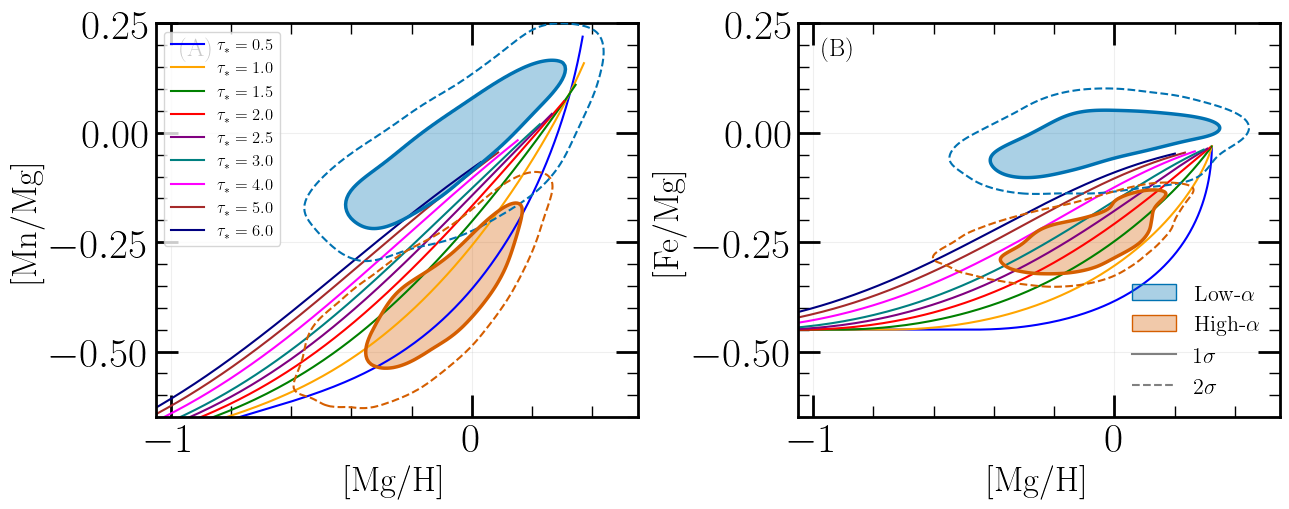

In [11]:
# Compute densities
dens_mnmg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["MN_MG"])
dens_mnmg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["MN_MG"])

dens_femg_low  = get_density(data_low_alpha["MG_H"], data_low_alpha["FE_MG"])
dens_femg_high = get_density(data_high_alpha["MG_H"], data_high_alpha["FE_MG"])

# Figure 
fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Panel A — [Mn/Mg]
ax = axes[0]
plot_sigma_contours(ax, dens_mnmg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_mnmg_high, HIGH_COLOR)
for i in range(len(gals_taustar_sfr1)):
    gal = gals_taustar_sfr1[i]
    ax.plot(gal.O_H, gal.Mn_O, color = colors_lines[i], linestyle='-', label = rf'$\tau_* = {gal.tau_star_arr[0]}$')
ax.legend(loc='upper left', fontsize=12)
ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Mn/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(A)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Panel B — [Fe/Mg]
ax = axes[1]
plot_sigma_contours(ax, dens_femg_low,  LOW_COLOR)
plot_sigma_contours(ax, dens_femg_high, HIGH_COLOR)
for i in range(len(gals_taustar_eta0)):
    gal = gals_taustar_eta0[i]
    ax.plot(gal.O_H, gal.Fe_O, color = colors_lines[i], linestyle='-')

ax.set_xlabel(r"[Mg/H]", fontsize = 25)
ax.set_ylabel(r"[Fe/Mg]", fontsize = 25)
ax.set_xlim(-1.05, 0.55)
ax.set_ylim(-0.65, 0.25)

#ax.set_box_aspect(1)

ax.grid(alpha=0.2)
ax.text(0.05, 0.92, "(B)", transform=ax.transAxes,
        fontsize=18, fontweight="bold")

# Legend (σ regions + populations + medians)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR,
                  label=r"Low-$\alpha$")

HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR,
                   label=r"High-$\alpha$")

SIG1 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="-", label=r"$1\sigma$")
SIG2 = Line2D([0], [0], color="gray", lw=1.5,
              linestyle="--", label=r"$2\sigma$")


ax.legend(
    handles=[LOW_PATCH, HIGH_PATCH, SIG1, SIG2],
    frameon=False, loc="lower right", fontsize=16,
)

plt.tight_layout()
plt.show()


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_72423/836064654.py:66: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


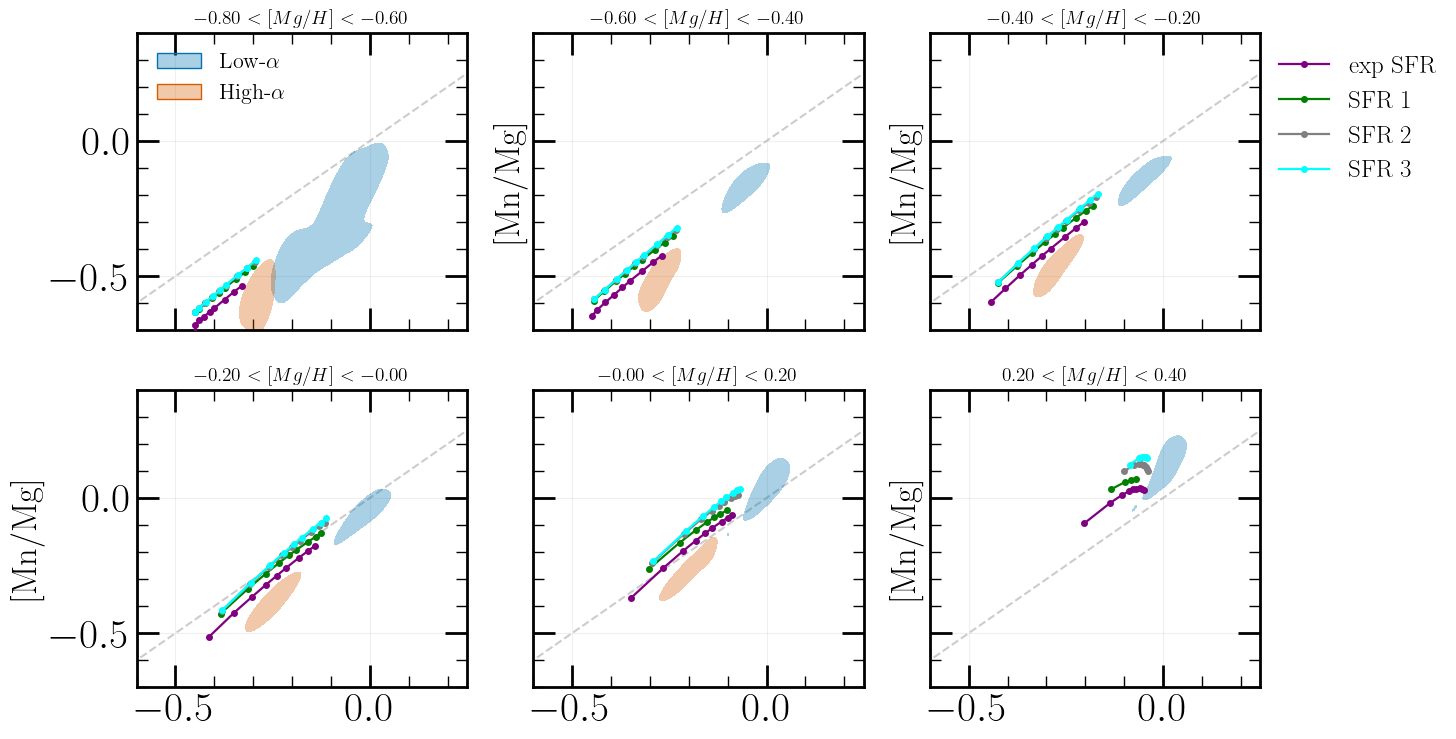

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [12]:
# Figure: 2 rows × 3 columns (panels 1–6)
fig, axes = plt.subplots(
    2, 3,
    figsize=(14.5, 8.5),
    sharex=True,
    sharey=True
)
axes = axes.flatten()
panel_ids = range(0, 6)  # panels 1–6 only


# Loop over panels
for idx, (ax, i) in enumerate(zip(axes, panel_ids)):

    df = data[data['MG_H_big_bin'] == i]
    df = downsample(df, 5000)


    # Diagonal reference line
    xs = np.linspace(-0.8, 0.4, 200)
    ax.plot(xs, xs, '--', color='gray', alpha=0.4, zorder=0)

    # KDE + 1σ contours per α population
    for label, color in [("low", LOW_COLOR), ("high", HIGH_COLOR)]:
        sub = df[df['high_low_alpha'] == label]
        if len(sub) < 200:
            continue
        dens = get_density(sub['FE_MG'].values, sub['MN_MG'].values)
        plot_1sigma_contour(ax, dens, color)


    # --- SFR tracks ---
    for sfr_key, color in sfr_colors.items():

        endpoints = gals_endpoints_sfr[sfr_key][i]
        galaxies  = sfr_gal_lists[sfr_key]

        fe_mg = []
        mn_mg = []

        for gal, idx in zip(galaxies, endpoints):
            fe_mg.append(gal.Fe_Mg[idx])
            mn_mg.append(gal.Mn_Mg[idx])

        ax.plot(
            fe_mg,
            mn_mg,
            color=color,
            marker='o',
            linewidth=1.6,
            markersize=4,
            label=sfr_labels[sfr_key],
            zorder=3
        )

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )

    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)

# Legend once
    axes[2].legend(
    loc='upper right',
    bbox_to_anchor=(1.6, 1.0),
    frameon=False
    )

    # Axis limits
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.70, 0.40)
    ax.grid(alpha=0.2)

    # Y-labels only on first column
    if idx % 3 == 0:
        ax.set_ylabel(r"[Mn/Mg]", fontsize=25)
    else:
        ax.set_ylabel("")

    # X-labels only on bottom row
    if idx // 3 == 1:
        ax.set_xlabel(r"[Fe/Mg]", fontsize=25)
    else:
        ax.set_xlabel("")

# Legend (first panel only)
LOW_PATCH = Patch(facecolor=LOW_COLOR+"55", edgecolor=LOW_COLOR, label=r"Low-$\alpha$")
HIGH_PATCH = Patch(facecolor=HIGH_COLOR+"55", edgecolor=HIGH_COLOR, label=r"High-$\alpha$")
SIG1 = Line2D([0], [0], color="gray", lw=2.0, linestyle="-", label=r"$1\sigma$")

axes[0].legend(handles=[LOW_PATCH, HIGH_PATCH], frameon=False, loc="upper left", fontsize=16)

plt.tight_layout()
plt.show()


In [13]:
def plot_mn_mg_vs_fe_mg_panels(
    gals_endpoints_sfr,
    sfr_gal_lists,
    sfr_colors,
    sfr_labels,
):
    """
    Produce the 2×3 [Mn/Mg] vs [Fe/Mg] panel figure with KDE contours
    and SFR tracks.

    Assumes the following exist in the global scope:
        data
        mg_h_big_bin_edges
        LOW_COLOR, HIGH_COLOR
        downsample
        get_density
        plot_1sigma_contour
        numpy as np
        matplotlib.pyplot as plt
        Patch, Line2D
    """

    # Figure: 2 rows × 3 columns (panels 1–6)
    fig, axes = plt.subplots(
        2, 3,
        figsize=(14.5, 8.5),
        sharex=True,
        sharey=True
    )
    axes = axes.flatten()
    panel_ids = range(0, 6)

    # Loop over panels
    for idx, (ax, i) in enumerate(zip(axes, panel_ids)):

        df = data[data['MG_H_big_bin'] == i]
        df = downsample(df, 5000)

        # Diagonal reference line
        xs = np.linspace(-0.8, 0.4, 200)
        ax.plot(xs, xs, '--', color='gray', alpha=0.4, zorder=0)

        # KDE + 1σ contours per α population
        for label, color in [("low", LOW_COLOR), ("high", HIGH_COLOR)]:
            sub = df[df['high_low_alpha'] == label]
            if len(sub) < 200:
                continue
            dens = get_density(sub['FE_MG'].values, sub['MN_MG'].values)
            plot_1sigma_contour(ax, dens, color)

        # --- SFR tracks ---
        for sfr_key, color in sfr_colors.items():

            endpoints = gals_endpoints_sfr[sfr_key][i]
            galaxies  = sfr_gal_lists[sfr_key]

            fe_mg = []
            mn_mg = []

            for gal, ep_idx in zip(galaxies, endpoints):
                fe_mg.append(gal.Fe_Mg[ep_idx])
                mn_mg.append(gal.Mn_Mg[ep_idx])

            ax.plot(
                fe_mg,
                mn_mg,
                color=color,
                marker='o',
                linewidth=1.6,
                markersize=5,
                label=sfr_labels[sfr_key],
                zorder=3
            )

        ax.set_title(
            rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
            fontsize=14
        )

        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(-0.70, 0.40)
        ax.grid(alpha=0.2)

        # Y-labels only on first column
        if idx % 3 == 0:
            ax.set_ylabel(r"[Mn/Mg]", fontsize=25)
        else:
            ax.set_ylabel("")

        # X-labels only on bottom row
        if idx // 3 == 1:
            ax.set_xlabel(r"[Fe/Mg]", fontsize=25)
        else:
            ax.set_xlabel("")

    # --- Legends ---
    LOW_PATCH  = Patch(facecolor=LOW_COLOR + "55", edgecolor=LOW_COLOR, label=r"Low-$\alpha$")
    HIGH_PATCH = Patch(facecolor=HIGH_COLOR + "55", edgecolor=HIGH_COLOR, label=r"High-$\alpha$")

    axes[0].legend(
        handles=[LOW_PATCH, HIGH_PATCH],
        frameon=False,
        loc="upper left",
        fontsize=16
    )

    axes[0].legend(
        loc='upper left',
    #    bbox_to_anchor=(1.6, 1.0),
        frameon=True
    )

    plt.tight_layout()
    plt.show()


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


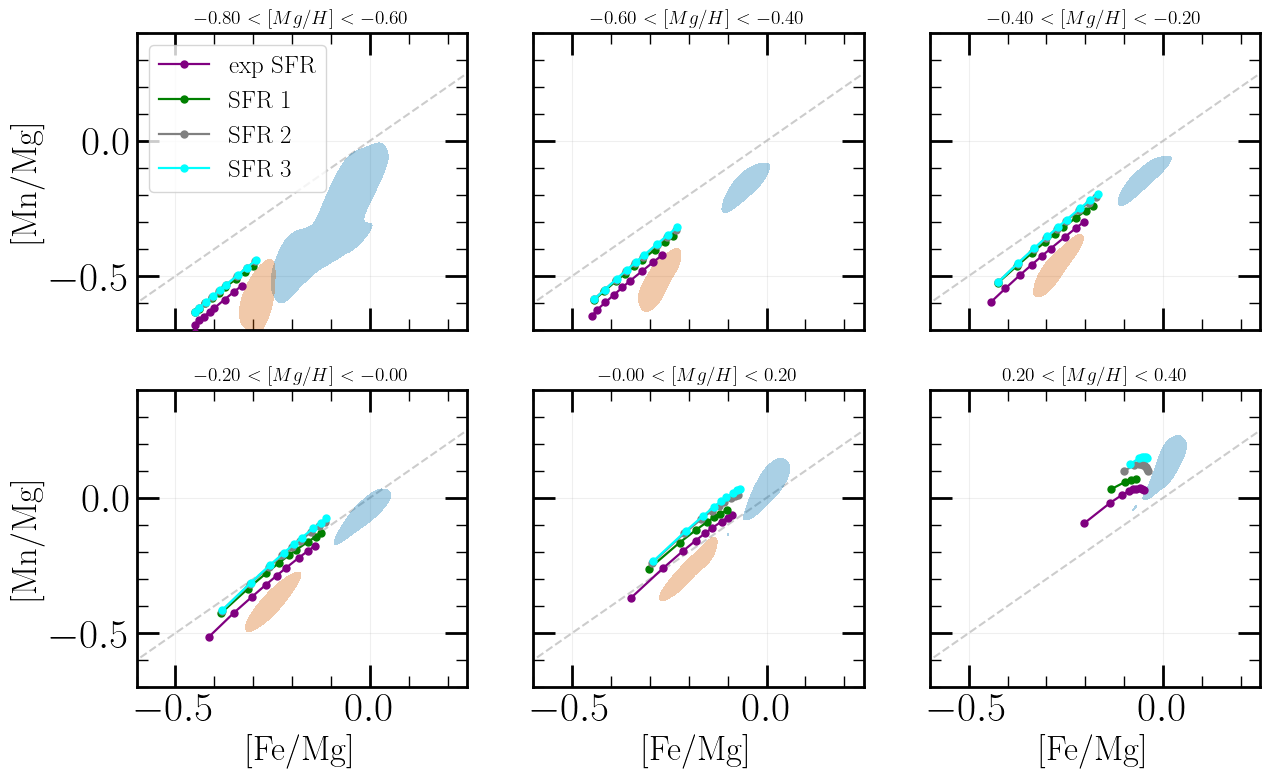

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [14]:
plot_mn_mg_vs_fe_mg_panels(gals_endpoints_sfr, sfr_gal_lists, sfr_colors, sfr_labels)

# R_IA

In [15]:
R_Ias = [0, 1, 1.97, 4]
ria_keys = ["0", "1", "2", "3"]

ria_gal_lists = {}

for key, R_Ia in zip(ria_keys, R_Ias):
    gals = []
    for i in range(len(tau_stars)):
        gals.append(
            evo.Galaxy(
                t_array=t_array,
                yields_ref="W2024,1.3",
                m_g_array=m_g_array_const,
                tau_star=tau_stars[i],
                eta=etas[0],
                R_Ia_Mn=R_Ia
            )
        )
    ria_gal_lists[key] = gals

gals_endpoints_ria = {
    key: find_endpoints(ria_gal_lists[key], mg_h_big_bin_centers)
    for key in ria_keys
}

ria_colors = {
    "0": "black",
    "1": "blue",
    "2": "orange",
    "3": "red",
}

ria_labels = {
    "0": r"$R_{\mathrm{Ia}} = 0$",
    "1": r"$R_{\mathrm{Ia}} = 1$",
    "2": r"$R_{\mathrm{Ia}} = 1.97$",
    "3": r"$R_{\mathrm{Ia}} = 4$",
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


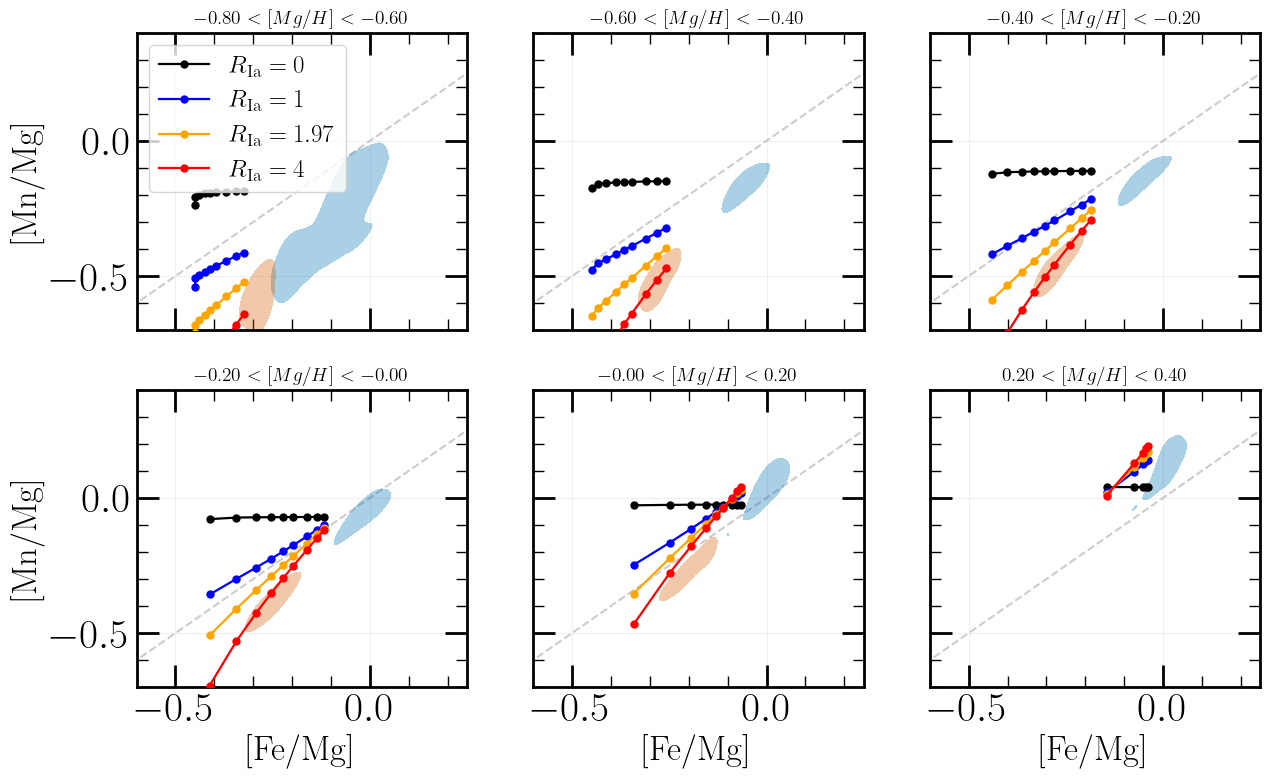

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [16]:
plot_mn_mg_vs_fe_mg_panels(gals_endpoints_ria, ria_gal_lists, ria_colors, ria_labels)

In [17]:
alpha_ccs = [0, 0.17, 0.5, 1]
alpha_cc_keys = ["0", "1", "2", "3"]

alpha_cc_gal_lists = {}

for key, alpha_cc in zip(alpha_cc_keys, alpha_ccs):
    gals = []
    for i in range(len(tau_stars)):
        gals.append(
            evo.Galaxy(
                t_array=t_array,
                yields_ref="W2024,1.3",
                m_g_array=m_g_array_const,
                tau_star=tau_stars[i],
                eta=etas[0],
                alpha_cc_Mn=alpha_cc
            )
        )
    alpha_cc_gal_lists[key] = gals

gals_endpoints_alpha_cc = {
    key: find_endpoints(alpha_cc_gal_lists[key], mg_h_big_bin_centers)
    for key in alpha_cc_keys
}

alpha_cc_colors = {
    "0": "black",
    "1": "blue",
    "2": "orange",
    "3": "red",
}

alpha_cc_labels = {
    "0": rf"$\alpha cc = {alpha_ccs[0]}$",
    "1": rf"$\alpha cc = {alpha_ccs[1]}$",
    "2": rf"$\alpha cc = {alpha_ccs[2]}$",
    "3": rf"$\alpha cc = {alpha_ccs[3]}$",
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


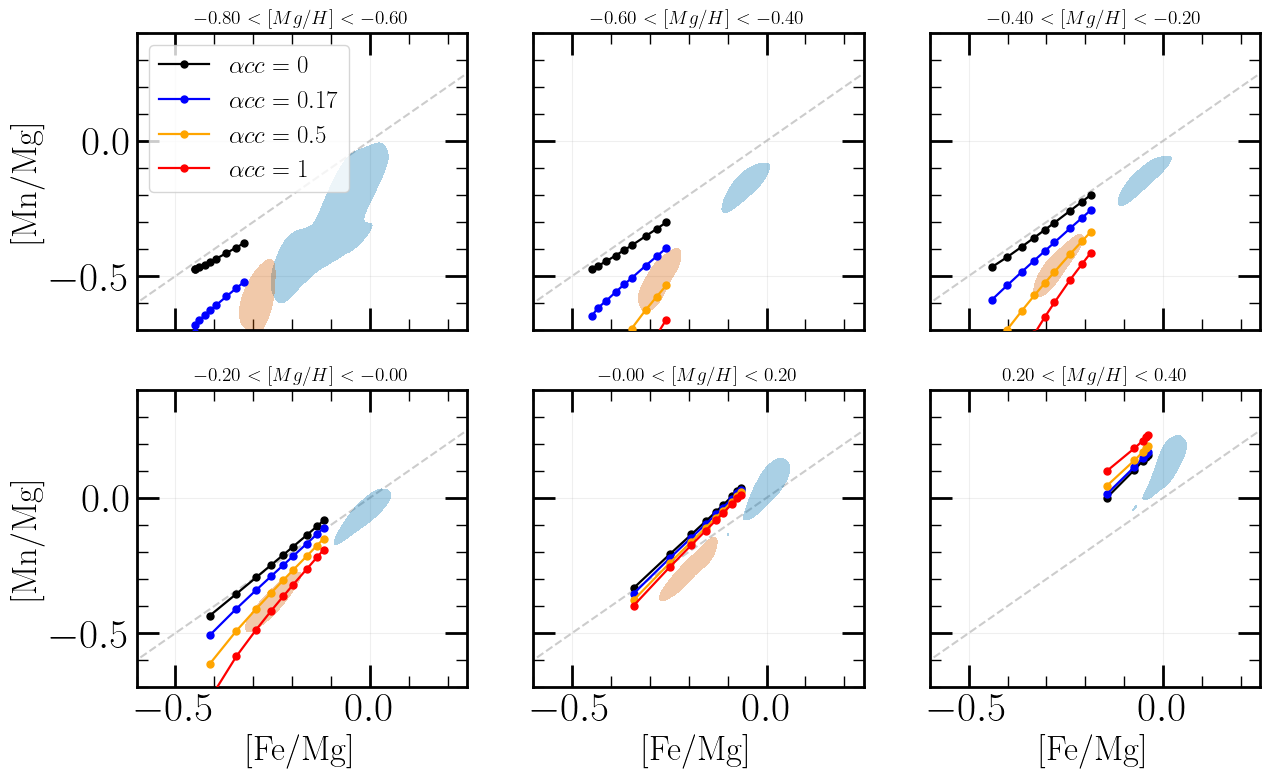

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [18]:
plot_mn_mg_vs_fe_mg_panels(gals_endpoints_alpha_cc, alpha_cc_gal_lists, alpha_cc_colors, alpha_cc_labels)

In [19]:
alpha_ias = [0, 0.3, 0.6, 1]
alpha_ia_keys = ["0", "1", "2", "3"]

alpha_ia_gal_lists = {}

for key, alpha_ia in zip(alpha_ia_keys, alpha_ias):
    gals = []
    for i in range(len(tau_stars)):
        gals.append(
            evo.Galaxy(
                t_array=t_array,
                yields_ref="W2024,1.3",
                m_g_array=m_g_array_const,
                tau_star=tau_stars[i],
                eta=etas[0],
                alpha_Ia_Mn=alpha_ia
            )
        )
    alpha_ia_gal_lists[key] = gals

gals_endpoints_alpha_ia = {
    key: find_endpoints(alpha_ia_gal_lists[key], mg_h_big_bin_centers)
    for key in alpha_ia_keys
}

alpha_ia_colors = {
    "0": "black",
    "1": "blue",
    "2": "orange",
    "3": "red",
}

alpha_ia_labels = {
    "0": rf"$\alpha Ia = {alpha_ias[0]}$",
    "1": rf"$\alpha Ia = {alpha_ias[1]}$",
    "2": rf"$\alpha Ia = {alpha_ias[2]}$",
    "3": rf"$\alpha Ia = {alpha_ias[3]}$",
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


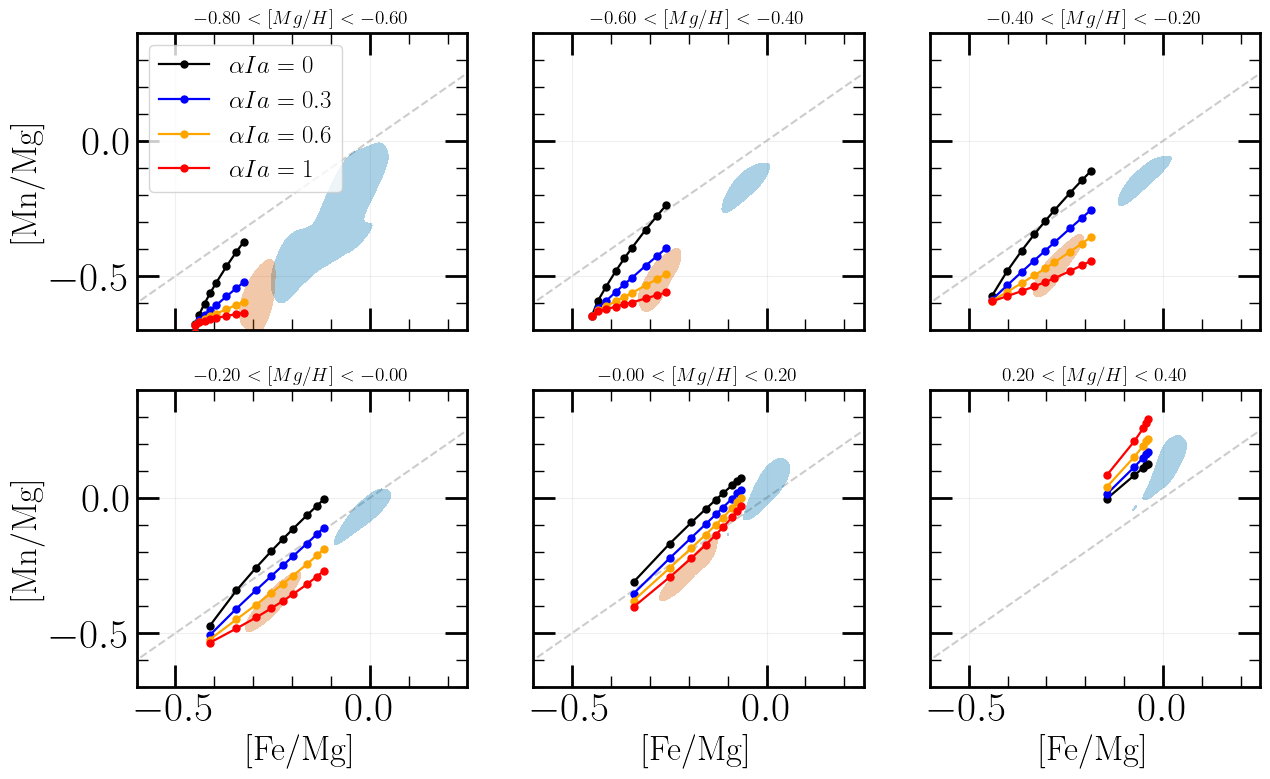

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [20]:
plot_mn_mg_vs_fe_mg_panels(gals_endpoints_alpha_ia, alpha_ia_gal_lists, alpha_ia_colors, alpha_ia_labels)

# YIELDS

In [21]:
yields = ["W2024", "W2024,double", "W2024,1.3", "W2024,0.7"]
yield_keys = ["0", "1", "2", "3"]

yield_gal_lists = {}

for key, y_name in zip(yield_keys, yields):
    gals = []
    for i in range(len(tau_stars)):
        gals.append(
            evo.Galaxy(
                t_array=t_array,
                yields_ref=y_name,
                m_g_array=m_g_array_const,
                tau_star=tau_stars[i],
                eta=etas[0]
            )
        )
    yield_gal_lists[key] = gals

gals_endpoints_yields = {
    key: find_endpoints(yield_gal_lists[key], mg_h_big_bin_centers)
    for key in yield_keys
}

yield_colors = {
    "0": "black",
    "1": "blue",
    "2": "orange",
    "3": "red",
}

yield_labels = {
    "0": f"{yields[0]}",
    "1": f"{yields[1]}",
    "2": f"{yields[2]}",
    "3": f"{yields[3]}",
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


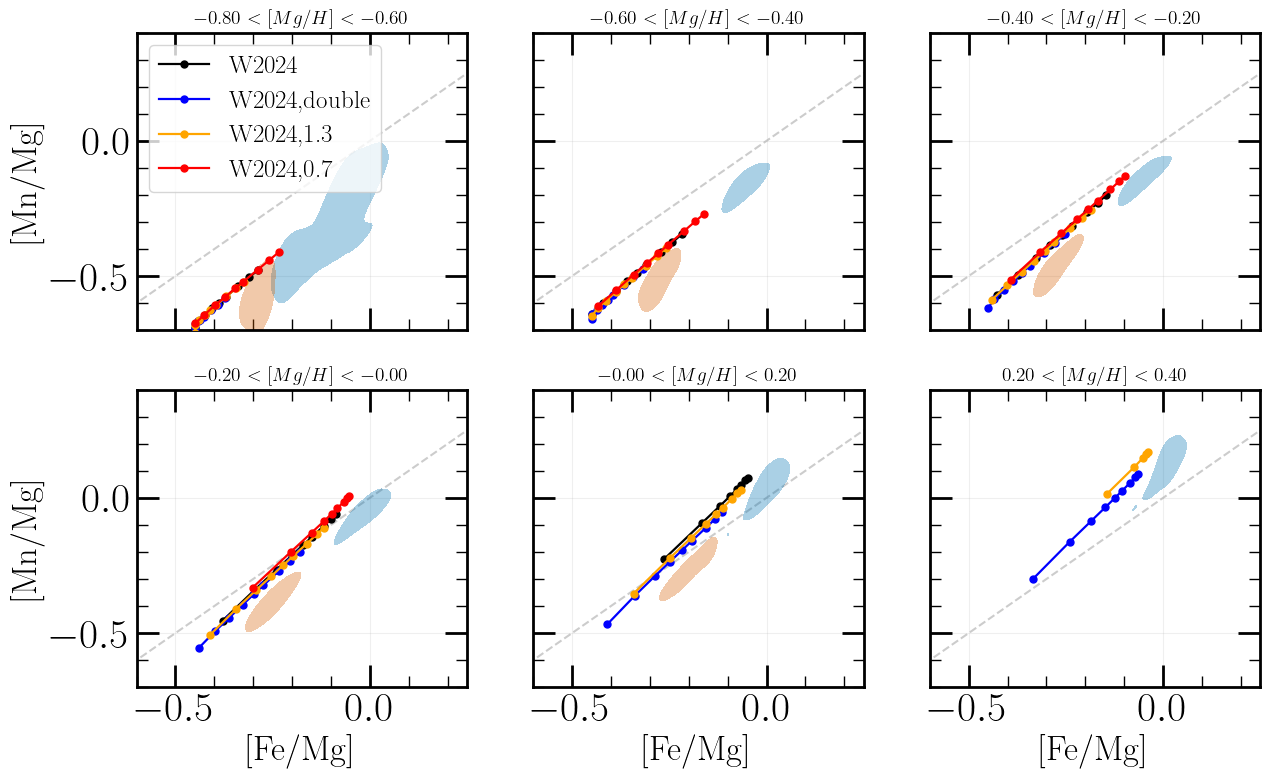

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [23]:
plot_mn_mg_vs_fe_mg_panels(gals_endpoints_yields, yield_gal_lists, yield_colors, yield_labels)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


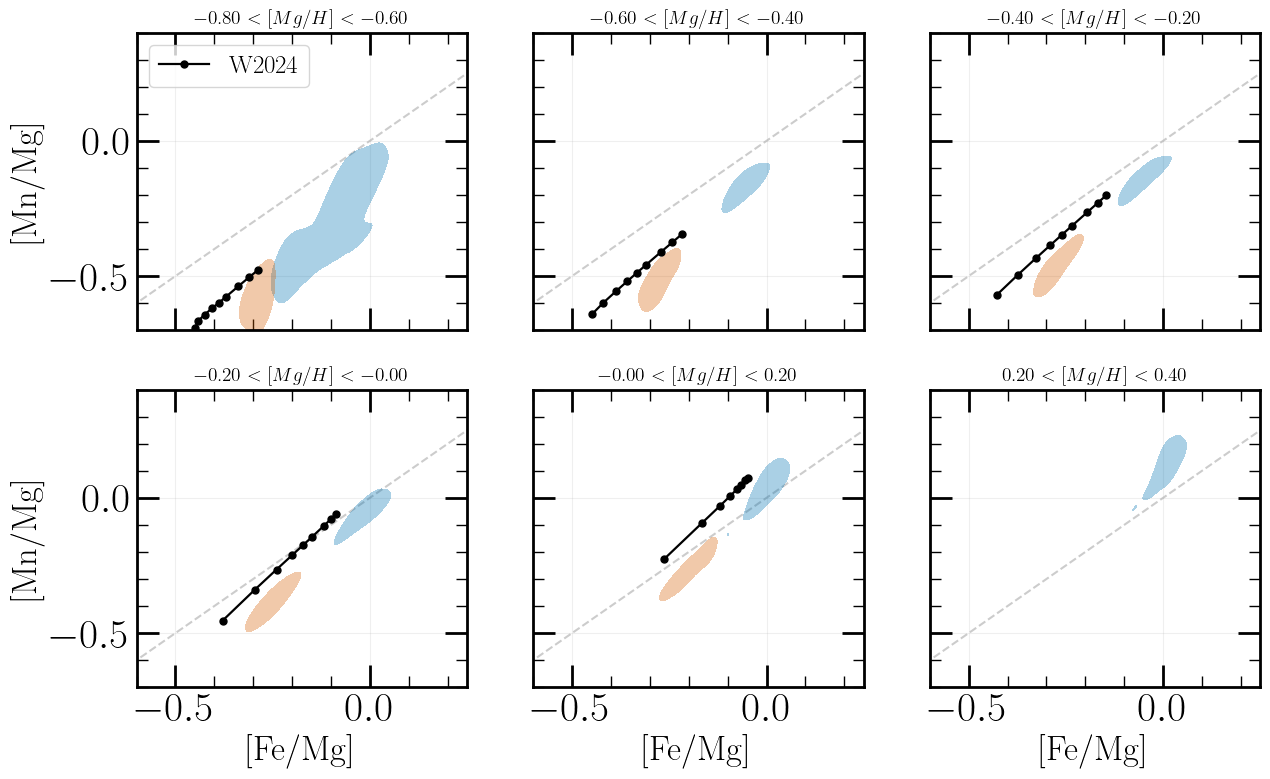

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [24]:
subset_keys = ["0"]   # NOT [0, 1]

gals_endpoints_subset = {k: gals_endpoints_yields[k] for k in subset_keys}
gal_lists_subset     = {k: yield_gal_lists[k]      for k in subset_keys}
colors_subset        = {k: yield_colors[k]         for k in subset_keys}
labels_subset        = {k: yield_labels[k]         for k in subset_keys}


plot_mn_mg_vs_fe_mg_panels(
    gals_endpoints_subset,
    gal_lists_subset,
    colors_subset,
    labels_subset
)


Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


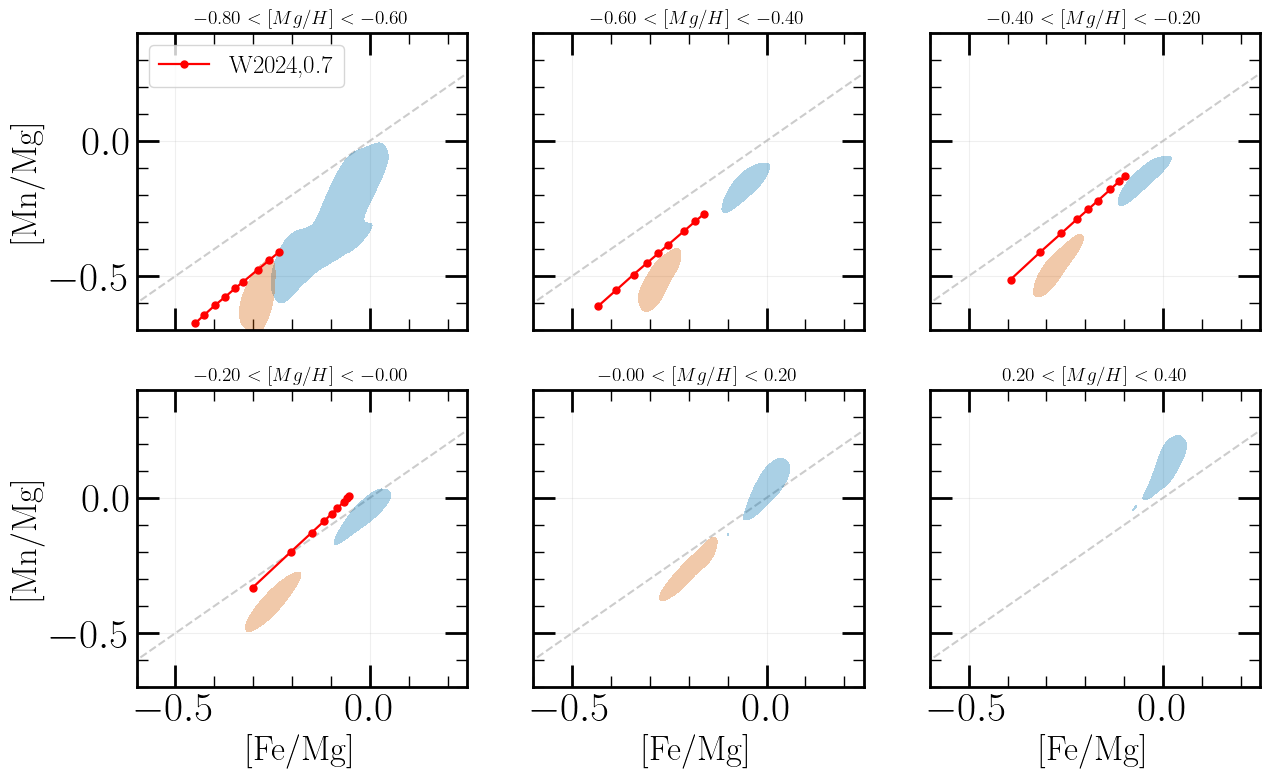

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [25]:
subset_keys = ["3"]   # NOT [0, 1]

gals_endpoints_subset = {k: gals_endpoints_yields[k] for k in subset_keys}
gal_lists_subset     = {k: yield_gal_lists[k]      for k in subset_keys}
colors_subset        = {k: yield_colors[k]         for k in subset_keys}
labels_subset        = {k: yield_labels[k]         for k in subset_keys}


plot_mn_mg_vs_fe_mg_panels(
    gals_endpoints_subset,
    gal_lists_subset,
    colors_subset,
    labels_subset
)


In [31]:
Mn_yields = [0.7, 1, 1.3, 2]
Mn_yield_keys = ["0", "1", "2", "3"]

Mn_yield_gal_lists = {}

for key, Mn_y in zip(Mn_yield_keys, Mn_yields):
    gals = []
    for i in range(len(tau_stars)):
        gals.append(
            evo.Galaxy(
                t_array=t_array,
                m_g_array=m_g_array_const,
                tau_star=tau_stars[i],
                eta=etas[0],
                Mn_cc_scale=Mn_y
            )
        )
    Mn_yield_gal_lists[key] = gals

gals_endpoints_Mn_yields = {
    key: find_endpoints(Mn_yield_gal_lists[key], mg_h_big_bin_centers)
    for key in Mn_yield_keys
}

Mn_yield_colors = {
    "0": "black",
    "1": "blue",
    "2": "orange",
    "3": "green"
}

Mn_yield_labels = {
    "0": f"scale = {Mn_yields[0]}",
    "1": f"scale = {Mn_yields[1]}",
    "2": f"scale = {Mn_yields[2]}",
    "3": f"scale = {Mn_yields[3]}"
}

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


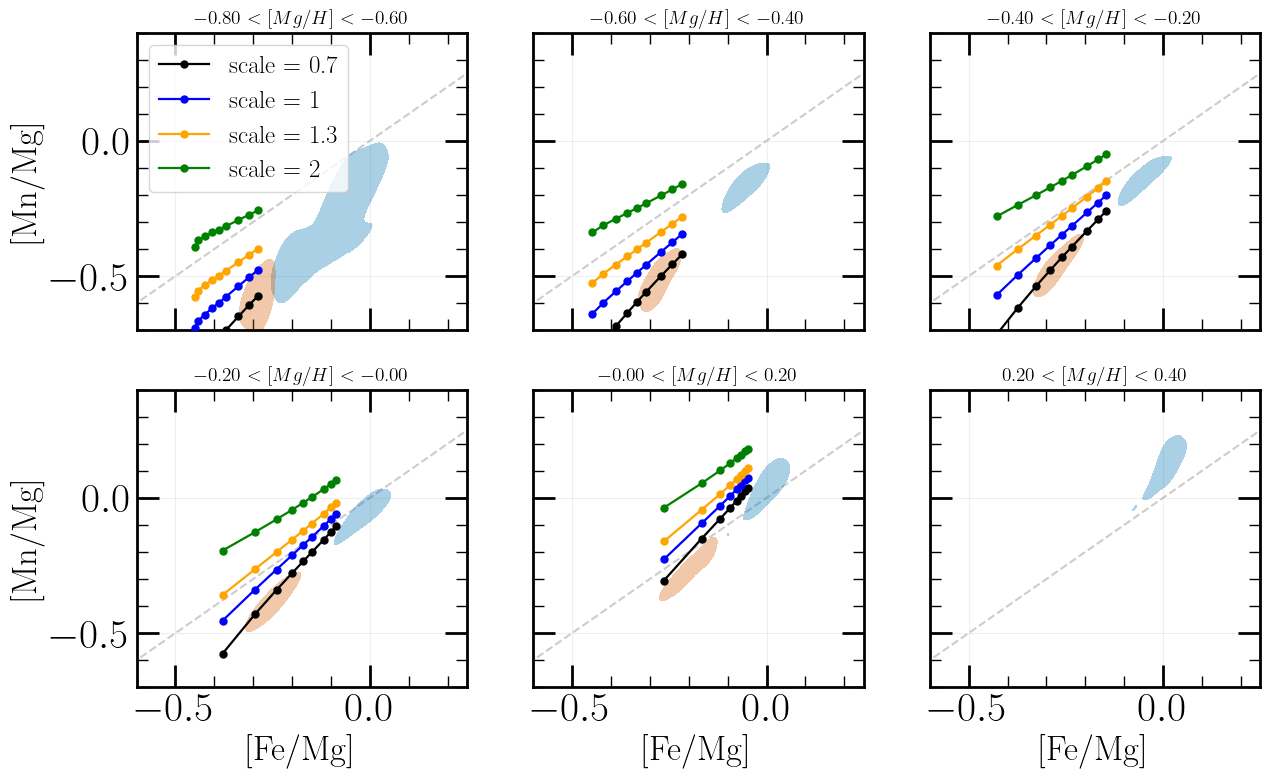

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

...

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

<Figure size 600x450 with 0 Axes>

In [32]:
subset_keys = ["0", "1", "2", "3"]   # NOT [0, 1]

gals_endpoints_subset = {k: gals_endpoints_Mn_yields[k] for k in subset_keys}
gal_lists_subset     = {k: Mn_yield_gal_lists[k]      for k in subset_keys}
colors_subset        = {k: Mn_yield_colors[k]         for k in subset_keys}
labels_subset        = {k: Mn_yield_labels[k]         for k in subset_keys}


plot_mn_mg_vs_fe_mg_panels(
    gals_endpoints_subset,
    gal_lists_subset,
    colors_subset,
    labels_subset
)